# Week 5 Day 4 Lab

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Function, Eq, dsolve, Derivative
from scipy.integrate import odeint
from scipy.integrate import solve_ivp

### Problem 1
Suppose 

$$\frac{dy}{dt}=1.2y.$$

instead of .5 from lecture. Solve again.

How does the graph change?



In [7]:
t = symbols('t')
y = Function('y')
ode = Eq(Derivative(y(t), t), 1.2 * y(t))
solution = dsolve(ode)
print("solution:")
display(solution)

solution:


Eq(y(t), C1*exp(1.2*t))

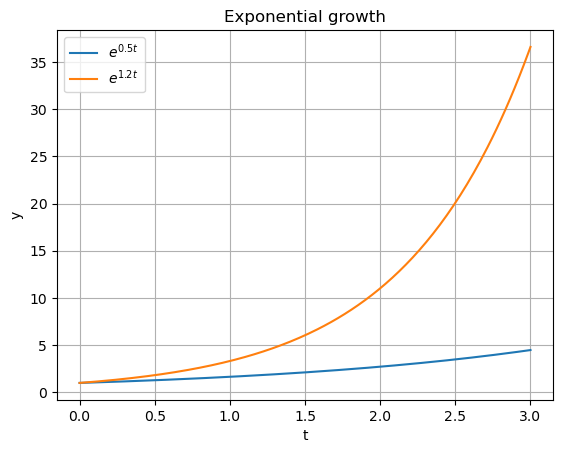

In [3]:
t = np.linspace(0, 3, 200)
y1 = np.exp(0.5 * t)
y2 = np.exp(1.2 * t)
plt.plot(t, y1, label=r"$e^{0.5t}$")
plt.plot(t, y2,  label=r"$e^{1.2t}$")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Exponential growth")
plt.legend()
plt.grid(True)
plt.show()

when using 1.2 the function grows much faster

### Problem 2

Solve

$$
\frac{dy}{dt}=3y
$$

with
$$
y(0)=2.
$$

Plot the solution.



In [8]:
t = symbols('t')
y = Function('y')
ode = Eq(Derivative(y(t), t), 3 * y(t))
solution = dsolve(ode, ics={y(0):2})
print("solution:")
display(solution)

solution:


Eq(y(t), 2*exp(3*t))

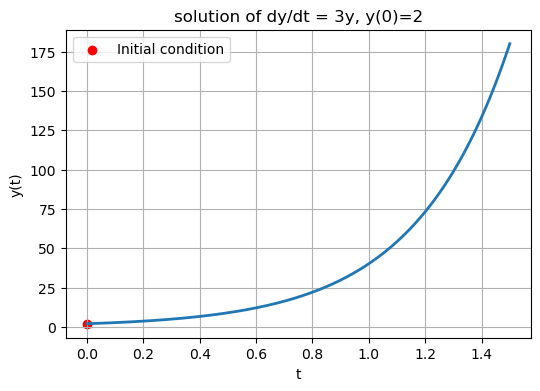

In [9]:
t = np.linspace(0, 1.5, 200)
y = 2 * np.exp(3 * t)
plt.figure(figsize=(6,4))
plt.plot(t, y, linewidth=2)
plt.scatter(0, 2, color = "red", label = "Initial condition")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("solution of dy/dt = 3y, y(0)=2")
plt.grid(True)
plt.legend()
plt.show()

### Problem 3

Solve

$$
\frac{dy}{dt}
=
-0.4y
$$

starting from

$$
y(0)=50.
$$


In [10]:
t = symbols('t')
y = Function('y')
ode = Eq(Derivative(y(t), t), -0.4 * y(t))
solution = dsolve(ode, ics={y(0):50})
print("solution:")
display(solution)

solution:


Eq(y(t), 50*exp(-0.4*t))

## Problem 4

Modify the logistic model by ranging $K$ from 0 to 50 with 100 slices.

How does the solution change?


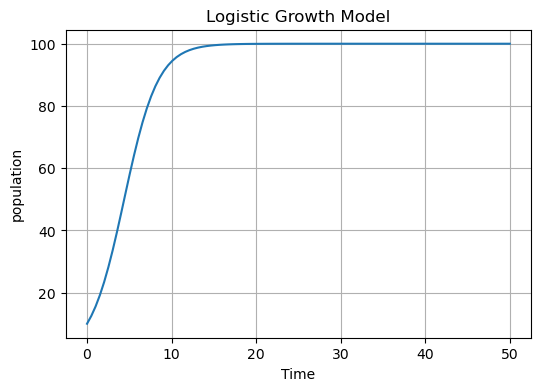

In [15]:
r = 0.5
k = 100
def logistic(y, t):
    return r * y * (1-y / k)
y0 = 10
t = np.linspace(0, 50, 100)
y = odeint(logistic, y0, t)
plt.figure(figsize=(6,4))
plt.plot(t, y)
plt.xlabel("Time")
plt.ylabel("population")
plt.title("Logistic Growth Model")
plt.grid(True)
plt.show()

## Problem 5

Create your own model.

Ideas include

- Predator-prey model
- Cooling of coffee
- Disease spread
- Population growth
- Bank account with continuous interest

Model the system using a differential equation and solve it with `solve_ivp()`

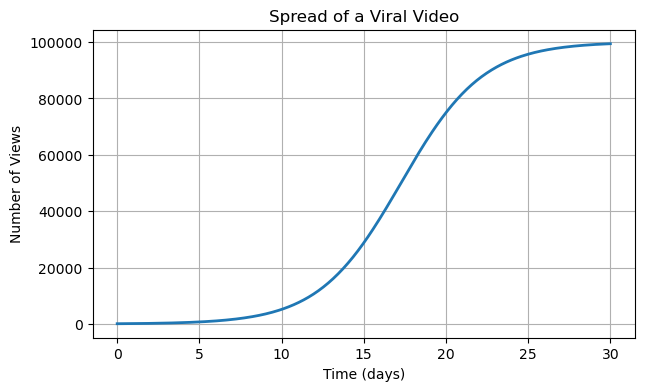

solution:


  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.003e-01 ...  2.990e+01  3.000e+01]
        y: [[ 1.000e+02  1.041e+02 ...  9.937e+04  9.939e+04]]
      sol: None
 t_events: None
 y_events: None
     nfev: 74
     njev: 0
      nlu: 0

In [22]:
def video_views(t, V):
    r = 0.4 
    K = 100000     
    return [r * V[0] * (1 - V[0] / K)]
V0 = [100]
t_span = (0, 30)
t_eval = np.linspace(0, 30, 300)
solution = solve_ivp(video_views, t_span, V0, t_eval=t_eval)
plt.figure(figsize=(7,4))
plt.plot(solution.t, solution.y[0], linewidth=2)
plt.xlabel("Time (days)")
plt.ylabel("Number of Views")
plt.title("Spread of a Viral Video")
plt.grid(True)
plt.show()
print("solution:")
display(solution)